In [1]:
# Code from Katharina to set up MPI
import os

# Use conda's newer libstdc++ instead of the system one
conda_lib = os.path.expanduser("~/.conda/envs/hnn-core-env/lib")
ld_path = os.environ.get("LD_LIBRARY_PATH", "")
os.environ["LD_LIBRARY_PATH"] = f"{conda_lib}:{ld_path}"

# UCX settings (from before)
os.environ["UCX_TLS"] = "tcp,self,sm"
os.environ["UCX_NET_DEVICES"] = "all"


# MPI paths
mpi_bin = "/oscar/rt/sw/external/hpcx-mpi/2.25.1/bin"
mpi_lib = "/oscar/rt/sw/external/hpcx-mpi/2.25.1/lib"
if mpi_bin not in os.environ["PATH"]:
    os.environ["PATH"] = f"{mpi_bin}:{os.environ['PATH']}"
if mpi_lib not in ld_path:
    os.environ["LD_LIBRARY_PATH"] = f"{mpi_lib}:{os.environ['LD_LIBRARY_PATH']}"

import sys
# Add MPI bin directory to PATH
mpi_bin = "/oscar/rt/sw/external/hpcx-mpi/2.25.1/bin"
if mpi_bin not in os.environ["PATH"]:
    os.environ["PATH"] = f"{mpi_bin}:{os.environ['PATH']}"

# print("Updated PATH to include MPI")
# print("MPI location:", mpi_bin)

import os
print("PATH:", os.environ.get('PATH', 'NOT SET'))
print("Which mpiexec:")
import subprocess
result = subprocess.run(['which', 'mpiexec'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else "mpiexec not found")

PATH: /oscar/rt/sw/external/hpcx-mpi/2.25.1/bin:/oscar/home/xgao35/venvs/hnn-core-calcium-202602/bin:/oscar/rt/9.6/25/x86_64_v3/code-server-4.96.4-2mbqypo7726gva5cbeogfppy2doijdhq/lib/vscode/bin/remote-cli:/users/xgao35/.pixi/bin:/users/xgao35/.conda/envs/hnn_core/bin:/oscar/runtime/bin:/oscar/rt/9.6/25/spack/x86_64_v3/code-server-4.96.4-2mbqypo7726gva5cbeogfppy2doijdhq/bin:/users/xgao35/.pixi/bin:/users/xgao35/miniconda3/bin:/users/xgao35/miniconda3/condabin:/users/xgao35/.conda/envs/hnn_core/bin:/usr/local/bin:/usr/bin:/usr/local/sbin:/usr/sbin:/usr/lpp/mmfs/bin:/usr/lpp/mmfs/sbin:/users/xgao35/bin:/users/xgao35/bin
Which mpiexec:
/oscar/rt/sw/external/hpcx-mpi/2.25.1/bin/mpiexec



In [2]:
import sys
import hnn_core
import os.path as op
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import numpy as np
import json

from hnn_core import duecker_ET_model, read_params, simulate_dipole, average_dipoles, read_dipole, Dipole
from hnn_core.viz import plot_dipole
from copy import deepcopy
from hnn_core import MPIBackend, hnn_io

--No graphics will be displayed.


In [3]:
# Read the network parameter 
net = hnn_io.read_network_configuration('/users/xgao35/Desktop/hnn_tep_modeling/Networks/BETA4_80_hand.json')

In [4]:
tstop=300
with MPIBackend(n_procs=6, mpi_cmd='mpiexec'):
    dpls = simulate_dipole(net, tstop=tstop, dt=0.025, n_trials=1, bsl_cor='duecker',record_ca='all',record_isec='all',record_vsec='all')

MPI will run 1 trial(s) sequentially by distributing network neurons over 6 processes.
numprocs=6
Loading custom mechanism files from /oscar/home/xgao35/Desktop/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Building the NEURON model
Loading custom mechanism files from /oscar/home/xgao35/Desktop/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /oscar/home/xgao35/Desktop/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /oscar/home/xgao35/Desktop/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /oscar/home/xgao35/Desktop/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
Loading custom mechanism files from /oscar/home/xgao35/Desktop/hnn-core/hnn_core/mod/x86_64/libnrnmech.so
[Done]
Trial 1: 0.03 ms...
Trial 1: 10.0 ms...
Trial 1: 20.0 ms...
Trial 1: 30.0 ms...
Trial 1: 40.0 ms...
Trial 1: 50.0 ms...
Trial 1: 60.0 ms...
Trial 1: 70.0 ms...
Trial 1: 80.0 ms...
Trial 1: 90.0 ms...
Trial 1: 100.0 ms...
Trial 1: 110

In [5]:
# Smooth and scale the dipole
dpls_smoothed = [dpl.smooth(20).scale(0.8) for dpl in dpls]

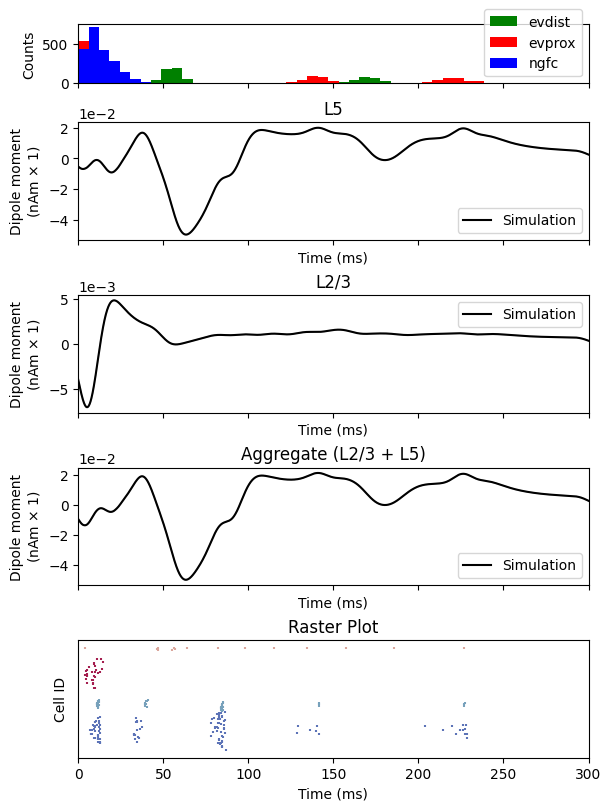

In [8]:
# Plotting the dipole and spiking for sanity check
from hnn_core.viz import plot_spikes_raster

fig, axes = plt.subplots(5, 1, figsize=(6, 8), constrained_layout=True, height_ratios=[1,2,2,2,2],sharex=True)

net.cell_response.plot_spikes_hist(ax=axes[0], spike_types=['evprox','evdist','ngfc'], trial_idx=0, show=False)

plot_dipole(dpls_smoothed.copy(), ax = axes[1], layer='L5', show=False, average=True,label='Simulation')
plot_dipole(dpls_smoothed.copy(), ax = axes[2], layer='L2', show=False, average=True,label='Simulation')
plot_dipole(dpls_smoothed.copy(), ax = axes[3], layer='agg', show=False, average=True,label='Simulation')

net.cell_response.plot_spikes_raster(ax=axes[4],show=False, show_legend=False)

plt.show()


Text(0, 0.5, 'Dipole Moment (nAm)')

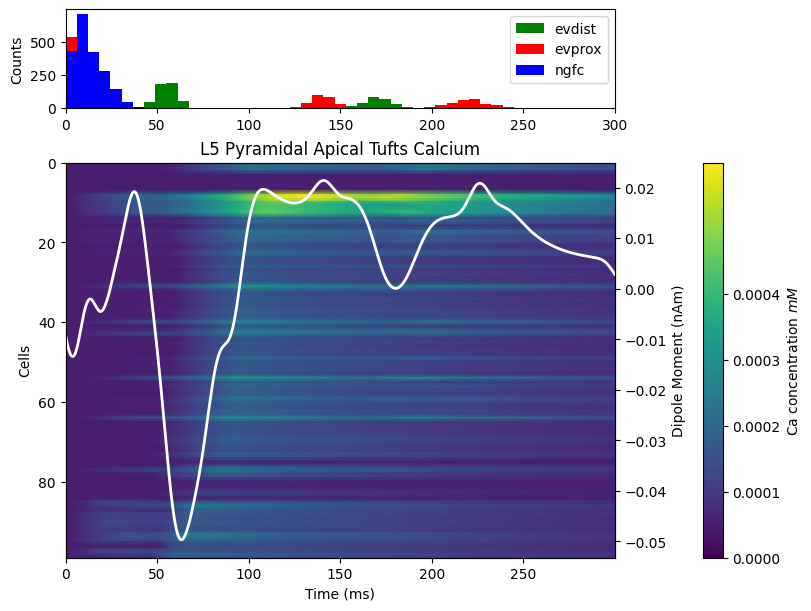

In [16]:
# get L5 pyramidal neuron id 
gids = net.gid_ranges
l5_gids = np.array(gids['L5_pyramidal'])

# get calcium for each cell tuft  
trial_idx = 0
ca_l5_tuft = np.zeros((l5_gids.shape[0], len(net.cell_response.times)))

for i, g in enumerate(l5_gids.astype(int)):
    ca_l5_tuft[i] = net.cell_response.ca[trial_idx][g]['apical_tuft']
    
# sorting the cells by their peak calcium concentration times
max_activation_times = np.argmax(ca_l5_tuft, axis=1)
sort_idx = np.argsort(max_activation_times)[::-1]
ca_l5_tuft_sort = ca_l5_tuft[sort_idx]

# plot 
fig, axes = plt.subplots(2, 1, sharex=False, figsize=(8, 6), constrained_layout=True, height_ratios=[1,4])
timevec = np.arange(0,len(net.cell_response.times),1)

net.cell_response.plot_spikes_hist(ax=axes[0], spike_types=['evprox','evdist','ngfc'], trial_idx=0, show=False)

# calcium concentration
im = axes[1].pcolormesh(timevec,np.arange(len(l5_gids)),ca_l5_tuft_sort, shading='gouraud',vmin=0, vmax=0.0006)
axes[1].invert_yaxis()
axes[1].set_title('L5 Pyramidal Apical Tufts Calcium')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Cells')

# add colorbar
cb = plt.colorbar(im, ax= axes[1], pad=0.03)
cb.set_ticks([0, 0.0001, 0.0002, 0.0003, 0.0004])
cb.set_label('Ca concentration $mM$')

# Total time in ms and number of points
n_points = len(timevec)

# Convert desired tick times (in ms) to indices in timevec
tick_times = np.arange(0, tstop-20+1, 50)  # 0, 50, ..., 300
tick_indices = (tick_times / tstop * n_points).astype(int)

# Set ticks and labels
axes[1].set_xticks(tick_indices)
axes[1].set_xticklabels(tick_times)
axes[1].set_xlim(0, n_points)
ax2 = axes[1].twinx()

# plot the dipole
ax2.plot(timevec,dpls_smoothed[0].data['agg'], color=(1,1,1), linewidth = 2)
ax2.set_ylabel('Dipole Moment (nAm)')

In [ ]:
# Plotting network calcium concentration snapshots 

In [ ]:
# Plotting NMDA current, Apical tuft voltage, and Mg block opening probability